# Part 1: Data Loading and Initial Exploration (15 pts)



## Part 1: Data Loading and Initial Exploration (15 pts)

The data for this project is stored in the `data` folder in your repositories, in the `SOTU.csv` file. The data file is structured as a CSV with columns for president name, speech text, year, and word count in the speech. 

In this section you will:

1. Import the data into a pandas dataframe
2. Perform exploratory data analysis (EDA) including specifically:
- Analyze the number of speeches per president
- Analyze the number of speeches per year
- Analyze the word count distribution
- Analyze the word count distribution accross years using a rug plot
- Analyze the average word count per president
3. Write commentary on your findings

First, create the `conda` environment with the provided yaml file. Note, it's not unusual for it to take ~15 minutes for the environment to fully install.

### Read Data

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-dark') 

In [3]:
# read in SOTU.csv using pandas, name the variable `sou` for simplicity
# the below cell is what the output should look like
sou = pd.read_csv('data/SOTU.csv')

In [4]:
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


### Exploratory Data Analysis

Replicate the plots below using the hints specified. For each plot, provide some commentary describing the results/anything interesting you might see.

#### Number of Speeches per President

In [5]:
# Hint - use value_counts() on the President column
# Hint - sort in order of dataframe
counts = sou['President'].value_counts().loc[sou['President'].unique()]
counts

President
Joseph R. Biden           4
Donald J. Trump           4
Barack Obama              8
George W. Bush            8
William J. Clinton        8
George Bush               4
Ronald Reagan             8
Jimmy Carter              7
Gerald R. Ford            3
Richard M. Nixon          6
Lyndon B. Johnson         6
John F. Kennedy           3
Dwight D. Eisenhower     10
Harry S Truman            8
Franklin D. Roosevelt    11
Herbert Hoover            4
Calvin Coolidge           6
Warren G. Harding         2
Woodrow Wilson            8
William Howard Taft       4
Theodore Roosevelt        8
William McKinley          4
Grover Cleveland          8
Benjamin Harrison         4
Chester A. Arthur         4
Rutherford B. Hayes       4
Ulysses S. Grant          8
Andrew Johnson            4
Abraham Lincoln           4
James Buchanan            4
Franklin Pierce           4
Millard Fillmore          3
Zachary Taylor            1
James K. Polk             4
John Tyler                4
Martin Van

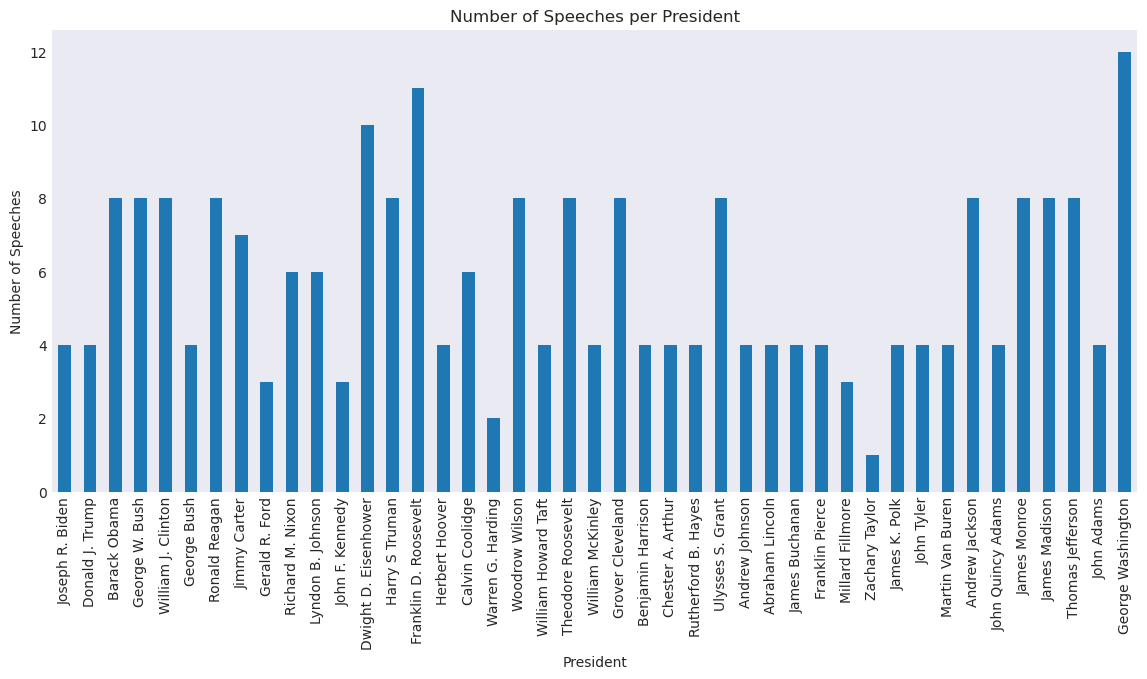

In [6]:
# Plot
# Hint - use the .plot() method for Pandas Series, make sure all presidents show up on x-axis
plt.figure(figsize=(14,6))
counts.plot(kind='bar')
plt.title("Number of Speeches per President")
plt.xlabel("President")
plt.ylabel("Number of Speeches")
plt.show()

George Washington delivered the largest number of State of the Union speeches (12), followed by Franklin D. Roosevelt (11), Dwight D. Eisenhower (10), and Harry S. Truman (8). Modern presidents typically deliver around 4–8 speeches, reflecting either limited years in office or modern transitions toward fewer formal annual addresses. Recent presidents such as Biden and Trump each have four speeches so far due to partial terms covered in this dataset.

#### Number of Speeches per Year

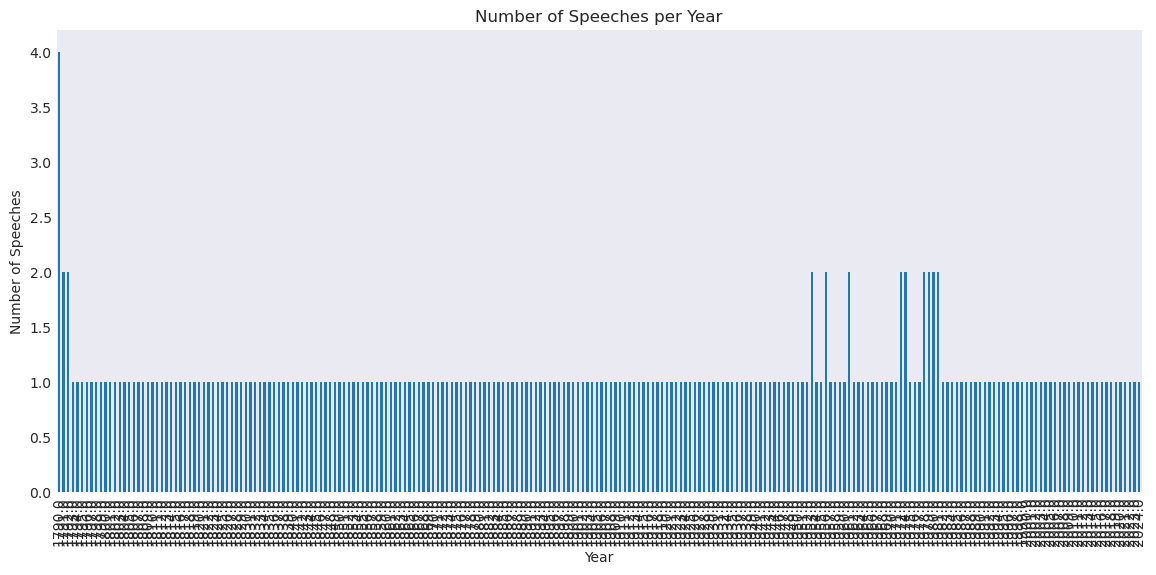

In [7]:
# Hint - Use value counts and sort by years
counts_year = sou['Year'].value_counts().sort_index()
plt.figure(figsize=(14,6))
counts_year.plot(kind='bar')
plt.title("Number of Speeches per Year")
plt.xlabel("Year")
plt.ylabel("Number of Speeches")
plt.show()

The distribution shows that most years contain exactly one State of the Union speech, since it is traditionally annual. The early years (1790–1792) include 2–4 speeches per year because multiple special sessions and messages were delivered. Exceptions in the dataset correspond to years where no speech was delivered, often due to national crises, transition periods, or presidential deaths. Extremely high counts early in U.S. history also reflect differences in how the SOTU was delivered before it became a single annual address.

In [8]:
# Hint - Use value counts and sort by years
counts_year = sou['Year'].value_counts().sort_index()
counts_year

Year
1790.0    4
1791.0    2
1792.0    2
1793.0    1
1794.0    1
         ..
2020.0    1
2021.0    1
2022.0    1
2023.0    1
2024.0    1
Name: count, Length: 232, dtype: int64

#### Word Count Distribution 

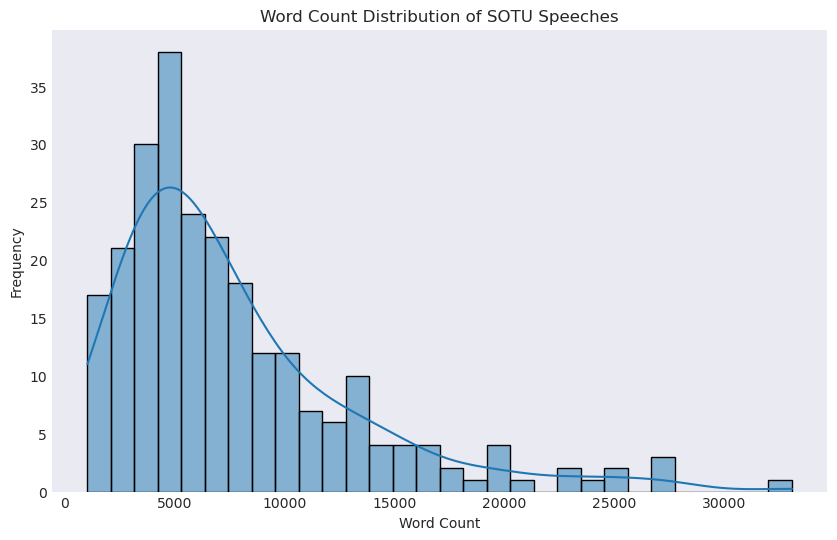

In [9]:
# Hint - try seaborn.histplot()
plt.figure(figsize=(10,6))
sns.histplot(data=sou, x='Word Count', bins=30, kde=True)
plt.title("Word Count Distribution of SOTU Speeches")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#### Word Count Distribution over Year

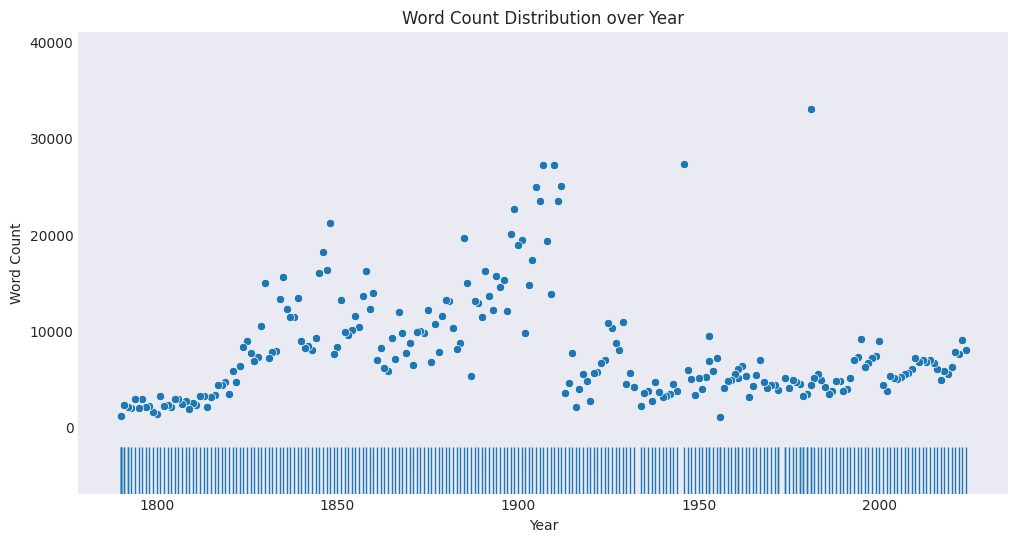

In [9]:
# Hint: try seaborn.rugplot()

plt.figure(figsize=(12,6))

sns.rugplot(data=sou, x='Year', height=0.1)
sns.scatterplot(data=sou, x='Year', y='Word Count')

plt.title("Word Count Distribution over Year")
plt.xlabel("Year")
plt.ylabel("Word Count")
plt.show()

The distribution is right-skewed, indicating that most State of the Union speeches contain between 3,000 and 8,000 words, with fewer extremely long speeches above 15,000 and some exceptional cases above 25,000. The long tail represents speeches from later presidents, who tend to give significantly longer addresses compared to early presidents, likely due to more complex policy agendas and modern communication expectations. Early speeches were short and often delivered in written form rather than orally.

#### Word Count Distribution per President

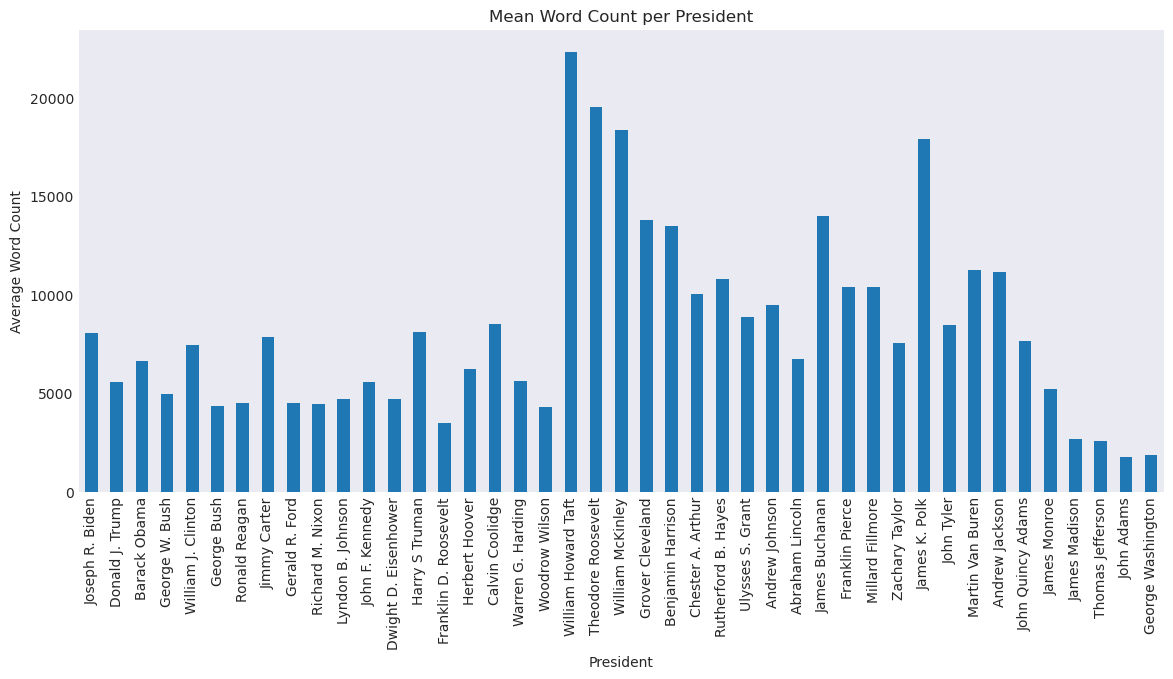

In [10]:
# Hint: use pandas groupby to get mean word count per president then sort by order
mean_wc = sou.groupby('President')['Word Count'].mean().loc[sou['President'].unique()]
plt.figure(figsize=(14,6))
mean_wc.plot(kind='bar')
plt.title("Mean Word Count per President")
plt.xlabel("President")
plt.ylabel("Average Word Count")
plt.show()